# NeuroSegment-BraTS: Treinamento do Modelo (Deep Learning)

**Notebook 4.2:** Modelagem e Experimentação — Swin UNETR

Nesta etapa, instanciamos a arquitetura **Swin UNETR**, definimos os parâmetros de otimização e executamos o ciclo de treinamento.

**Metodologia Experimental:**
*   **Modelo:** Swin UNETR (Swin Transformer como encoder + decoder U-Net). Captura contexto global longo via self-attention hierárquica, diferindo da U-Net 3D que usa apenas convoluções locais.
*   **Função de Perda:** `DiceCELoss`. Combinação de *Cross-Entropy* (classificação geral) com *Dice Loss* (desbalanceamento de classes).
*   **Otimizador:** AdamW (variante do Adam com decaimento de peso separado, recomendado para Transformers).
*   **Gestão de Hardware:** `use_checkpoint=True` para economia de VRAM via gradient checkpointing. Validação via `SlidingWindowInferer`.

## 1. Importações e Inicialização

In [1]:
import os
import torch
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete
import matplotlib.pyplot as plt

# Definindo o dispositivo de aceleração (CUDA/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinamento rodando no dispositivo: {device}")

# Limpeza preventiva do Cache da GPU
if device.type == 'cuda':
    torch.cuda.empty_cache()

# Post-processing para validação: converte logits e labels para one-hot
post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Treinamento rodando no dispositivo: cuda


## 2. Ingestão do Pipeline de Dados
Abaixo, conectamos este notebook aos iteradores criados no Notebook 3.

In [2]:
import sys
sys.path.append('../')
from src.data_pipeline import get_dataloaders

# 1. Ingestão do Pipeline
train_loader, val_loader = get_dataloaders()
print("DataLoaders carregados com sucesso no Notebook 4.2!")

# Validando a conexão
test_batch = next(iter(train_loader))
print(f"Shape de entrada da imagem: {test_batch['image'].shape}") 
# Esperado: (Batch, Canais, X, Y, Z) -> ex: (1, 4, 96, 96, 96)

Total de pacientes carregados na tubulação: 368
DataLoaders carregados com sucesso no Notebook 4.2!


/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Shape de entrada da imagem: torch.Size([2, 4, 96, 96, 96])


## 3. Definição da Arquitetura (Swin UNETR) e Hiperparâmetros
Configuramos o Swin UNETR para aceitar 4 canais de entrada (FLAIR, T1, T1ce, T2) e devolver predições para as nossas 4 classes de interesse.

**Diferenciais do Swin UNETR:**
- Usa **Swin Transformer** no encoder: divide o volume em janelas 3D e calcula self-attention localmente, depois desloca as janelas na próxima camada para capturar interações entre regiões distantes.
-  (reduzido do padrão 48) para caber em GPUs com ~12GB VRAM.
-  ativa gradient checkpointing: troca computação por memória, recalculando ativações no backward ao invés de armazená-las.

In [3]:
# 1. O Modelo: Swin UNETR
model = SwinUNETR(
    in_channels=4,               # 4 Modalidades (FLAIR, T1, T1ce, T2)
    out_channels=4,              # 4 Classes de saída (Background, NCR, ED, ET)
    feature_size=12,             # Reduzido de 24 para caber em GPUs com ~12GB VRAM
    use_checkpoint=True,         # Gradient checkpointing: troca memória por computação
).to(device)

# 2. A Função de Perda (Loss Function)
loss_function = DiceCELoss(to_onehot_y=True, softmax=True)

# 3. O Otimizador: AdamW (recomendado para Transformers)
learning_rate = 1e-4
weight_decay = 1e-5
optimizer = torch.optim.AdamW(model.parameters(), learning_rate, weight_decay=weight_decay)

# 4. A Métrica de Avaliação Oficial (Dice Score)
dice_metric = DiceMetric(include_background=False, reduction="mean")

print(f"Modelo Swin UNETR instanciado com {sum(p.numel() for p in model.parameters()):,} parâmetros")

Modelo Swin UNETR instanciado com 4,079,386 parâmetros


## 4. O Ciclo de Treinamento e Validação
Executamos o treinamento iterativo. A cada *batch*, o modelo tenta segmentar o tumor, calcula o erro e ajusta seus pesos. Ao final de cada época, rodamos uma etapa de validação (sem aprender) para medir a performance real.

In [4]:
# Configurações do Loop
max_epochs = 10 # LEMBRAR DE MUDAR PARA A RODADA REAL <------------------------
val_interval = 4  # Roda validação a cada 4 épocas

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

print("INICIANDO O TREINAMENTO (Swin UNETR)...")

for epoch in range(max_epochs):
    print(f"\n--- Época {epoch + 1}/{max_epochs} ---")
    
    # === MODO DE TREINO ===
    model.train()
    epoch_loss = 0
    step = 0
    
    for batch_data in train_loader:
        step += 1
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        if step % 10 == 0:
            print(f"Lote {step}/{len(train_loader)} | Loss do Lote: {loss.item():.4f}")
            
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"--> Loss Médio da Época {epoch + 1}: {epoch_loss:.4f}")
    
    # === MODO DE VALIDAÇÃO ===
    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs = val_data["image"].to(device)
                val_labels = val_data["label"].to(device)
                
                # Sliding Window: processa o cérebro inteiro em pedaços de 96x96x96
                val_outputs = sliding_window_inference(
                    inputs=val_inputs, 
                    roi_size=(96, 96, 96), 
                    sw_batch_size=4, 
                    predictor=model
                )
                
                # Post-processing correto: argmax + one-hot para predições e labels
                val_outputs = [post_pred(i) for i in val_outputs]
                val_labels = [post_label(i) for i in val_labels]
                
                dice_metric(y_pred=val_outputs, y=val_labels)
            
            metric = dice_metric.aggregate().item()
            dice_metric.reset()
            metric_values.append(metric)
            
            print(f">>> Métrica Dice de Validação: {metric:.4f}")
            
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), os.path.join("../models", "best_metric_model_swin_unetr.pth"))
                print("Novo recorde! Modelo salvo no disco.")

print(f"\nTREINAMENTO CONCLUÍDO! Melhor Dice: {best_metric:.4f} na época {best_metric_epoch}")

INICIANDO O TREINAMENTO (Swin UNETR)...

--- Época 1/10 ---
Lote 10/328 | Loss do Lote: 1.8695
Lote 20/328 | Loss do Lote: 1.6936
Lote 30/328 | Loss do Lote: 1.7012
Lote 40/328 | Loss do Lote: 1.5634
Lote 50/328 | Loss do Lote: 1.5137
Lote 60/328 | Loss do Lote: 1.6440
Lote 70/328 | Loss do Lote: 1.5763
Lote 80/328 | Loss do Lote: 1.5802
Lote 90/328 | Loss do Lote: 1.3966
Lote 100/328 | Loss do Lote: 1.4824
Lote 110/328 | Loss do Lote: 1.4700
Lote 120/328 | Loss do Lote: 1.4436
Lote 130/328 | Loss do Lote: 1.4594
Lote 140/328 | Loss do Lote: 1.3966
Lote 150/328 | Loss do Lote: 1.3479
Lote 160/328 | Loss do Lote: 1.2743
Lote 170/328 | Loss do Lote: 1.3426
Lote 180/328 | Loss do Lote: 1.3507
Lote 190/328 | Loss do Lote: 1.3240
Lote 200/328 | Loss do Lote: 1.3263
Lote 210/328 | Loss do Lote: 1.2601
Lote 220/328 | Loss do Lote: 1.3094
Lote 230/328 | Loss do Lote: 1.3715
Lote 240/328 | Loss do Lote: 1.2007
Lote 250/328 | Loss do Lote: 1.3161
Lote 260/328 | Loss do Lote: 1.2904
Lote 270/328 

/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/

>>> Métrica Dice de Validação: 0.4772
Novo recorde! Modelo salvo no disco.

--- Época 5/10 ---
Lote 10/328 | Loss do Lote: 0.7712
Lote 20/328 | Loss do Lote: 0.6576
Lote 30/328 | Loss do Lote: 0.9129
Lote 40/328 | Loss do Lote: 0.6933
Lote 50/328 | Loss do Lote: 0.7581
Lote 60/328 | Loss do Lote: 0.9167
Lote 70/328 | Loss do Lote: 0.8555
Lote 80/328 | Loss do Lote: 0.9257
Lote 90/328 | Loss do Lote: 0.9041
Lote 100/328 | Loss do Lote: 0.6701
Lote 110/328 | Loss do Lote: 0.6865
Lote 120/328 | Loss do Lote: 0.9000
Lote 130/328 | Loss do Lote: 0.7061
Lote 140/328 | Loss do Lote: 0.7362
Lote 150/328 | Loss do Lote: 0.6681
Lote 160/328 | Loss do Lote: 0.8156
Lote 170/328 | Loss do Lote: 0.7352
Lote 180/328 | Loss do Lote: 0.6421
Lote 190/328 | Loss do Lote: 0.7240
Lote 200/328 | Loss do Lote: 0.6634
Lote 210/328 | Loss do Lote: 0.7110
Lote 220/328 | Loss do Lote: 0.7129
Lote 230/328 | Loss do Lote: 0.9923
Lote 240/328 | Loss do Lote: 0.8958
Lote 250/328 | Loss do Lote: 0.6595
Lote 260/328 |

## 5. Curvas de Aprendizado
Visualização da evolução do loss de treino e do Dice de validação ao longo das épocas.

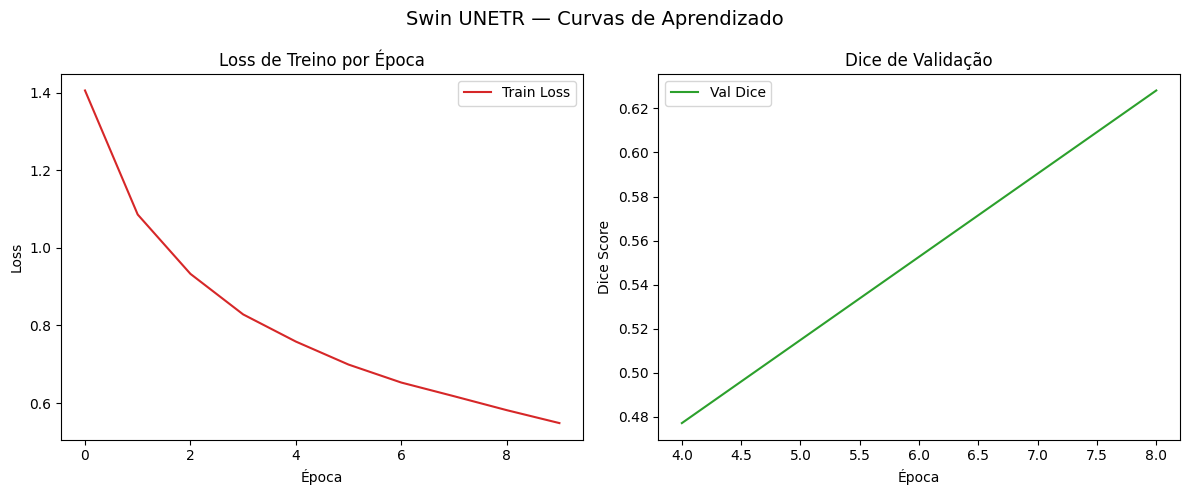

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Curva de Loss de Treino
ax1.plot(epoch_loss_values, label='Train Loss', color='tab:red')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Loss de Treino por Época')
ax1.legend()

# Curva de Dice de Validação
val_epochs = [i * val_interval for i in range(1, len(metric_values) + 1)]
ax2.plot(val_epochs, metric_values, label='Val Dice', color='tab:green')
ax2.set_xlabel('Época')
ax2.set_ylabel('Dice Score')
ax2.set_title('Dice de Validação')
ax2.legend()

plt.suptitle('Swin UNETR — Curvas de Aprendizado', fontsize=14)
plt.tight_layout()
plt.savefig('../models/swin_unetr_learning_curves.png', dpi=150)
plt.show()